In [10]:
!git clone https://github.com/directedbyshawn/ML-FINAL-PROJECT.git

Cloning into 'ML-FINAL-PROJECT'...
remote: Enumerating objects: 8023, done.
remote: Counting objects: 100% (8023/8023), done.
remote: Compressing objects: 100% (7982/7982), done.
remote: Total 8023 (delta 32), reused 8007 (delta 21), pack-reused 0
Receiving objects: 100% (8023/8023), 34.45 MiB | 5.51 MiB/s, done.
Resolving deltas: 100% (32/32), done.


# Image classification

Different Object recognition tasks

Image classification is a task where an image is classified into one or multiple classes based on the task.
Input: an image
Output: one or multiple class(es)

Image/Object localization is a regression problem where the output is x and y coordinates around the object of interest to draw bounding boxes.
Input: an image
Output: “x”, “y”, height, and width numbers around an object of interest

Object detection is a complex problem that combines the concepts of image localization and classification. Given an image, an object detection algorithm would return bounding boxes around all objects of interest and assign a class to them.
Input: an image
Output: “x”, “y”, height, and width numbers around all object of interest along with class(es)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import imageio
import glob
import cv2
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dropout, Flatten
from keras.layers.convolutional import Conv2D, MaxPooling2D
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix



2022-10-31 17:56:58.739468: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-10-31 17:56:59.667949: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/dmytro/.local/lib/python3.8/site-packages/cv2/../../lib64:
2022-10-31 17:56:59.668000: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2022-10-31 17:56:59.804796: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already b

In [2]:
def divide_data(train, test):
    # 60, 20, 20
    # set aside 20% of train and test data for evaluation
    X_train, X_test, y_train, y_test = train_test_split(
        train, test, test_size=0.2, shuffle=True, random_state=42)

    # Use the same function above for the validation set
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train, y_train, test_size=0.25, shuffle=True, random_state=42)  # 0.25 x 0.8 = 0.2

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def load_data():
    train = []
    test = []
    
    for n_class in range(0, 43):

        path = os.getcwd() + "/data/" + str(n_class) + "/"

        class_train = []
        
        for im_path in glob.glob(path + "*.png"):
            image = imageio.v2.imread(im_path)

            class_train.append(image)

        # to "normalize" the number of each class
        if len(class_train) > 150:
            np.random.shuffle(class_train)
            class_train = class_train[:150][:][:]

        train.extend(class_train)
        test.extend([n_class] * len(class_train))


    train = np.array(train)
    test = np.array(test)

    X_train, X_valid, X_test, y_train, y_valid, y_test = divide_data(train, test)

    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [22]:
X_train, X_valid, X_test, y_train, y_valid, y_test = load_data()
print(X_train.shape, X_valid.shape, X_test.shape,y_train.shape, y_valid.shape, y_test.shape)

(1914, 32, 32, 3) (638, 32, 32, 3) (638, 32, 32, 3) (1914,) (638,) (638,)


In [4]:
def grayscale(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image


def equalize(image):
    image = cv2.equalizeHist(image)
    return image


def preprocessing(image):
    image = grayscale(image)
    image = equalize(image)
    image = image/255
    return image

In [23]:
X_train = np.array(list(map(preprocessing, X_train)))
X_valid = np.array(list(map(preprocessing, X_valid)))
X_test = np.array(list(map(preprocessing, X_test)))

X_train = X_train.reshape(X_train.shape[0], 32, 32, 1)
X_valid = X_valid.reshape(X_valid.shape[0], 32, 32, 1)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 1)

y_train = to_categorical(y_train, 43)
y_valid = to_categorical(y_valid, 43)
y_test = to_categorical(y_test, 43)

In [24]:
print(X_train.shape, X_valid.shape, X_test.shape,y_train.shape, y_valid.shape, y_test.shape)

(1914, 32, 32, 1) (638, 32, 32, 1) (638, 32, 32, 1) (1914, 43) (638, 43) (638, 43)


In [7]:
def compile_model():
    model = Sequential()
    model.add(Conv2D(60, (5, 5), input_shape=(32, 32, 1), activation='relu'))
    model.add(Conv2D(60, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(30, (3, 3), activation='relu'))
    model.add(Conv2D(30, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(500, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(43, activation='softmax'))

    # Compile Model
    model.compile(Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
model = compile_model()
print(model.summary())

2022-10-31 17:57:34.427819: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/dmytro/.local/lib/python3.8/site-packages/cv2/../../lib64:
2022-10-31 17:57:34.428478: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2022-10-31 17:57:34.428541: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (dmytro-Lenovo-V330-14ARR): /proc/driver/nvidia/version does not exist
2022-10-31 17:57:34.430207: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 60)        1560      
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 60)        90060     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 60)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 30)        16230     
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 30)          8130      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 30)         0         
 2D)                                                    

In [9]:
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), batch_size=32, epochs=10)
print(history)

Epoch 1/10
60/60 [==============================] - 40s 641ms/step - loss: 3.1050 - accuracy: 0.1933 - val_loss: 1.3836 - val_accuracy: 0.6850
Epoch 2/10
60/60 [==============================] - 38s 628ms/step - loss: 0.8496 - accuracy: 0.7638 - val_loss: 0.3311 - val_accuracy: 0.9201
Epoch 3/10
60/60 [==============================] - 37s 617ms/step - loss: 0.3541 - accuracy: 0.9018 - val_loss: 0.2443 - val_accuracy: 0.9279
Epoch 4/10
60/60 [==============================] - 37s 616ms/step - loss: 0.2340 - accuracy: 0.9284 - val_loss: 0.2105 - val_accuracy: 0.9436
Epoch 5/10
60/60 [==============================] - 41s 686ms/step - loss: 0.1570 - accuracy: 0.9519 - val_loss: 0.1933 - val_accuracy: 0.9451
Epoch 6/10
60/60 [==============================] - 42s 709ms/step - loss: 0.1168 - accuracy: 0.9650 - val_loss: 0.1982 - val_accuracy: 0.9514
Epoch 7/10
60/60 [==============================] - 48s 801ms/step - loss: 0.1116 - accuracy: 0.9650 - val_loss: 0.1374 - val_accuracy: 0.9608

In [10]:
predict_x = model.predict(X_test)

20/20 [==============================] - 4s 188ms/step


In [25]:
score = model.evaluate(X_test, y_test, verbose=0)

print('Test Score:', score[0])
print('Test Accuracy:', score[1])

Test Score: 0.12480910122394562
Test Accuracy: 0.9608150720596313


In [11]:
y_pred = []
for y in predict_x:
    pred = np.argmax(y)
    y_pred.append(pred)
    
y_my_test = []
for y in y_test:
    pred = np.argmax(y)
    y_my_test.append(pred)

y_pred = np.array(y_pred)
y_test = np.array(y_my_test)

In [12]:
precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

(0.9134480719853167, 0.8987241988242954, 0.9034465799019945, None)

In [44]:
confusion_matrix(y_test, y_pred)

array([[36,  0,  0, ...,  0,  0,  0],
       [ 0, 23,  1, ...,  0,  1,  0],
       [ 0,  2, 32, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 19,  0,  0],
       [ 0,  0,  0, ...,  0,  8,  0],
       [ 0,  0,  0, ...,  0,  0,  3]])

Text(0.5, 0, 'Epoch')

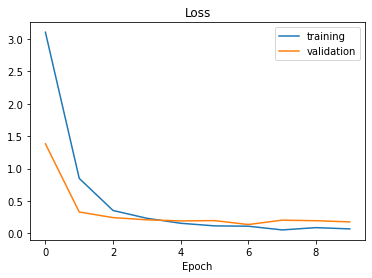

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training','validation'])
plt.title('Loss')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

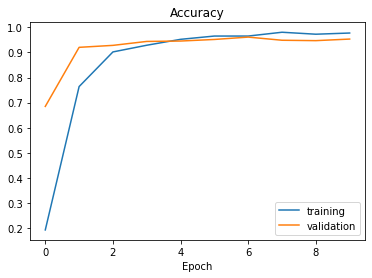

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training','validation'])
plt.title('Accuracy')
plt.xlabel('Epoch')

